03_data_cleaning.ipynb

├── 1. Introduction
│
├── 2. What Does "Clean Data" Mean?
│
├── 3. Missing Value Investigation
│
├── 4. Duplicate Detection
│
├── 5. Data Type Validation
│
├── 6. Consistency Checks
│
├── 7. Outlier Investigation
│
├── 8. Data Leakage Assessment
│
├── 9. Cleaning Strategy Summary
│
├── 10. Implement Cleaning Decisions
│
├── 11. Validation After Cleaning
│
└── 12. Export Clean Dataset

03_data_cleaning.ipynb

1. Missing Value Investigation

2. Missing Value Treatment

3. Duplicate Investigation

4. Outlier Investigation

5. Data Type Corrections

6. Final Clean Dataset

# Data Cleaning

## 1. Introduction

After exploring the dataset during Exploratory Data Analysis (EDA), the next step in the machine learning workflow is to assess and improve data quality.

Importantly, not every unusual observation requires modification or removal. Throughout this notebook, every cleaning decision will be based on evidence gathered during the reconnaissance and EDA phases, combined with domain knowledge of the Ames Housing dataset. The objective is not simply to eliminate imperfections, but to preserve meaningful information while addressing issues that could negatively affect model performance or interpretation.

## 2. Objectives

The primary objectives of this notebook are:

- Investigate missing values and determine their underlying causes.
- Detect duplicate records and assess whether they require removal.
- Validate feature data types and identify inconsistencies.
- Examine potential data quality issues, including invalid values and logical inconsistencies.
- Investigate outliers to distinguish genuine observations from possible data entry errors.
- Assess the dataset for potential sources of data leakage.
- Define a justified cleaning strategy based on evidence rather than assumptions.
- Produce a cleaned dataset for feature engineering and preprocessing.

In [2]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

## 3. Missing Value Investigation

In [3]:
df = pd.read_csv("../data/raw/test.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [4]:
missing_values = df.isnull().sum().to_frame('Missing Count').sort_values(by='Missing Count', ascending=False)
missing_values["Percentage"] = (missing_values["Missing Count"] / len(df)) * 100
missing_values = missing_values[missing_values["Missing Count"] > 0]
missing_values

,Missing Count,Percentage
PoolQC,1456,99.794380
MiscFeature,1408,96.504455
Alley,1352,92.666210
Fence,1169,80.123372
MasVnrType,894,61.274846
FireplaceQu,730,50.034270
LotFrontage,227,15.558602
GarageYrBlt,78,5.346127
GarageCond,78,5.346127
GarageFinish,78,5.346127


### Observations

Several features contain missing values, although the extent of missingness varies considerably across the dataset.

Features such as **PoolQC**, **MiscFeature**, **Alley**, **Fence**, and **FireplaceQu** exhibit the highest percentages of missing values. Based on the findings from the EDA phase and the feature descriptions, these missing values are likely to indicate the absence of the corresponding property characteristic rather than incomplete data collection.

Similarly, many garage and basement related features contain missing values that are expected for properties without garages or basements. Consequently, these features should not automatically be treated as data quality issues requiring imputation.

However, certain variables such as **LotFrontage**, **MasVnrArea**, and **Electrical** require further investigation, as their missing values may represent genuinely unavailable information rather than the absence of a feature.

### Decision

At this stage, no missing values will be modified.

Instead, each feature containing missing values will be investigated individually to determine whether the missingness represents:

- the absence of a property feature,
- genuinely unknown information, or
- a potential data quality issue.

Cleaning decisions will therefore be made on a feature-by-feature basis rather than applying a uniform imputation strategy.

### Grouping Features by Missingness Pattern

The missing values observed in the dataset are not randomly distributed across features. Instead, many of them belong to related feature groups that describe the same property characteristic.

Grouping features based on their business meaning allows similar missingness patterns to be investigated together, reducing repetitive analysis and ensuring consistent cleaning decisions across related variables.

| Feature Group       | Features                                                                                                                                 | Initial Interpretation              |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------- | ----------------------------------- |
| **Pool**            | PoolQC                                                                                                                                   | Likely no pool                      |
| **Miscellaneous**   | MiscFeature                                                                                                                              | Likely no miscellaneous feature     |
| **Alley**           | Alley                                                                                                                                    | No alley access                     |
| **Fence**           | Fence                                                                                                                                    | No fence                            |
| **Masonry Veneer**  | MasVnrType, MasVnrArea                                                                                                                   | Requires investigation              |
| **Fireplace**       | FireplaceQu                                                                                                                              | No fireplace                        |
| **Lot Information** | LotFrontage                                                                                                                              | Requires investigation              |
| **Garage**          | GarageType, GarageFinish, GarageQual, GarageCond, GarageYrBlt, GarageCars, GarageArea                                                    | Mostly properties without garages   |
| **Basement**        | BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, BsmtFullBath, BsmtHalfBath, TotalBsmtSF | Mostly properties without basements |
| **Other Features**  | MSZoning, Utilities, Exterior1st, Exterior2nd, KitchenQual, Functional, SaleType                                                         | Requires investigation              |


### Amenity-Related Features

#### PoolQC

##### Question

Do the missing values in `PoolQC` represent missing information, or do they indicate properties without a swimming pool?

In [5]:
df["PoolQC"].value_counts(dropna=False)

PoolQC
NaN    1456
Ex        2
Gd        1
Name: count, dtype: int64

In [6]:
df[["PoolArea", "PoolQC"]].sort_values("PoolArea", ascending=False).head(10)


,PoolArea,PoolQC
1250,800,Gd
1139,561,NaN
1043,444,NaN
960,368,NaN
1113,228,Ex
514,144,Ex
1445,0,NaN
1446,0,NaN
1447,0,NaN
1448,0,NaN


In [7]:
df[df["PoolQC"].isna() & (df["PoolArea"] > 0)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
960,2421,20,RL,75.0,9532,Pave,NaN,Reg,Lvl,AllPub,...,0,368,NaN,GdPrv,NaN,0,2,2007,WD,Normal
1043,2504,50,RL,104.0,23920,Pave,NaN,Reg,Lvl,AllPub,...,0,444,NaN,NaN,NaN,0,4,2007,WD,Normal
1139,2600,20,RL,200.0,43500,Pave,NaN,Reg,Lvl,AllPub,...,0,561,NaN,GdPrv,NaN,0,6,2007,WD,Normal


##### Observations

`PoolQC` contains missing values for 1,456 out of 1,460 properties (99.79%), making it the feature with the highest proportion of missing data in the dataset.

To investigate the nature of these missing values, the relationship between `PoolQC` and `PoolArea` was examined. The analysis showed that the overwhelming majority of missing `PoolQC` values correspond to properties with a recorded `PoolArea` of zero, suggesting that these missing values represent the absence of a swimming pool rather than incomplete data.

However, three properties were identified with non-zero pool areas despite having missing `PoolQC` values. These observations indicate rare inconsistencies or incomplete records within the dataset rather than missingness.

#### MiscFeature

In [8]:
df["MiscFeature"].value_counts(dropna=False)


MiscFeature
NaN     1408
Shed      46
Gar2       3
Othr       2
Name: count, dtype: int64

In [9]:
df[df["MiscFeature"].isna() & (df["MiscVal"] > 0)]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1089,2550,20,RL,128.0,39290,Pave,NaN,IR1,Bnk,AllPub,...,0,0,NaN,NaN,NaN,17000,10,2007,New,Partial


#### Alley

In [10]:
df["Alley"].value_counts(dropna=False)


Alley
NaN     1352
Grvl      70
Pave      37
Name: count, dtype: int64

#### Fence

In [11]:
df["Fence"].value_counts(dropna=False)


Fence
NaN      1169
MnPrv     172
GdPrv      59
GdWo       58
MnWw        1
Name: count, dtype: int64

##### Observations

The features `MiscFeature`, `Alley`, and `Fence` contain a high proportion of missing values. According to the Ames Housing dataset documentation, missing values in these features indicate the absence of the corresponding property characteristic rather than incomplete data collection.

To further validate this interpretation, `MiscFeature` was compared against `MiscVal`. The analysis showed that only a single property had a non-zero miscellaneous feature value despite a missing `MiscFeature` entry, indicating a rare inconsistency rather than a systematic pattern. Similar numerical validation is not possible for `Alley` and `Fence`, as no corresponding quantitative features exist. Therefore, the dataset documentation serves as the primary source of evidence for interpreting their missing values.

#### FireplaceQu

In [12]:
df["FireplaceQu"].value_counts(dropna=False)


FireplaceQu
NaN    730
Gd     364
TA     279
Fa      41
Po      26
Ex      19
Name: count, dtype: int64

In [13]:
df[df["FireplaceQu"].isna() & (df["Fireplaces"] > 0)]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


In [14]:
df[["Fireplaces", "FireplaceQu"]].sort_values(by="Fireplaces", ascending=False).head(10)


,Fireplaces,FireplaceQu
1250,4,TA
1425,3,Gd
949,3,TA
1251,3,TA
200,3,Gd
1107,3,TA
1291,3,Gd
746,2,Gd
691,2,Gd
702,2,Gd


##### Observations

The Ames Housing documentation defines missing values in `FireplaceQu` as properties without a fireplace. This interpretation was further validated by comparing `FireplaceQu` with the `Fireplaces` feature, which showed that missing quality ratings are associated with properties containing no fireplaces.

Therefore, the missing values in `FireplaceQu` represent the absence of the feature rather than incomplete data.

#### Overall Conclusion

The amenity-related features (`PoolQC`, `MiscFeature`, `Alley`, `Fence`, and `FireplaceQu`) exhibit missing values that primarily represent the absence of optional property characteristics rather than incomplete data collection. This interpretation is supported by the Ames Housing dataset documentation and, where possible, validated through exploratory analysis.

Although a small number of anomalous records were identified (e.g., three properties with non-zero pool areas but missing `PoolQC`, and one property with a non-zero miscellaneous feature value despite a missing `MiscFeature` entry), these inconsistencies are rare and do not materially affect the overall interpretation of the missing values.

#### Overall Decision

The missing values in the amenity-related features will be interpreted as representing the absence of the corresponding property characteristic. Consequently, missing values in `PoolQC`, `MiscFeature`, `Alley`, `Fence`, and `FireplaceQu` will be replaced with `"None"` during the cleaning process to explicitly encode the absence of these amenities while preserving their semantic meaning.

### Garage Related Features

In [15]:
garage_cols = [
    "GarageType",
    "GarageYrBlt",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "GarageCars",
    "GarageArea",
]

df[garage_cols].isnull().sum()


GarageType      76
GarageYrBlt     78
GarageFinish    78
GarageQual      78
GarageCond      78
GarageCars       1
GarageArea       1
dtype: int64

In [16]:
df[df["GarageType"].isna()][garage_cols]


,GarageType,GarageYrBlt,GarageFinish,GarageQual,GarageCond,GarageCars,GarageArea
53,NaN,NaN,NaN,NaN,NaN,0.0,0.0
71,NaN,NaN,NaN,NaN,NaN,0.0,0.0
79,NaN,NaN,NaN,NaN,NaN,0.0,0.0
92,NaN,NaN,NaN,NaN,NaN,0.0,0.0
96,NaN,NaN,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...
1433,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1449,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1453,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1454,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [17]:
df[df["GarageCars"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1116,2577,70,RM,50.0,9060,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2007,WD,Alloca


In [18]:
df[df["GarageArea"].isna()]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
1116,2577,70,RM,50.0,9060,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2007,WD,Alloca


In [19]:
df[df["GarageType"].isna()]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
53,1514,90,RL,98.0,13260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,1,2010,Oth,Abnorml
71,1532,30,RM,56.0,4485,Pave,Grvl,Reg,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,5,2010,WD,Normal
79,1540,190,RM,100.0,9045,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Abnorml
92,1553,70,RM,60.0,12900,Pave,Grvl,Reg,Lvl,AllPub,...,168,0,NaN,NaN,NaN,0,5,2010,WD,Normal
96,1557,190,RL,60.0,9900,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2010,ConLD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1433,2894,50,C (all),60.0,8520,Grvl,NaN,Reg,Bnk,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal
1449,2910,180,RM,21.0,1470,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Normal
1453,2914,160,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal


##### Observations

The garage-related features exhibit a clear and consistent missingness pattern. Most missing values occur together across multiple garage attributes, indicating that they describe the same underlying condition rather than independent data quality issues.

Inspection of the affected records shows that non-garage features remain populated while garage-related attributes are predominantly missing. This localized pattern suggests that the properties themselves are complete, but simply do not contain a garage.

Additionally, `GarageCars` and `GarageArea` each contain a single missing value that belongs to the same observation, indicating an isolated data inconsistency rather than a systematic missingness pattern.

These findings are consistent with the Ames Housing dataset documentation, which defines missing garage-related values as properties without garages.

#### Decision

The missing values in the garage-related features will be interpreted as representing the absence of a garage rather than incomplete data collection.

Categorical garage features (`GarageType`, `GarageFinish`, `GarageQual`, and `GarageCond`) will be encoded as `"None"` to explicitly indicate the absence of a garage.

The isolated missing values in `GarageCars` and `GarageArea` will be investigated separately during the implementation phase to determine the most appropriate treatment.

The numerical garage features will be imputed using values that preserve the semantic meaning of properties without garages while maintaining consistency across the garage feature family.

### Basement Related Features

In [20]:
bsmt_cols = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
]

df[bsmt_cols].isnull().sum()


BsmtQual        44
BsmtCond        45
BsmtExposure    44
BsmtFinType1    42
BsmtFinType2    42
BsmtFinSF1       1
BsmtFinSF2       1
BsmtUnfSF        1
TotalBsmtSF      1
BsmtFullBath     2
BsmtHalfBath     2
dtype: int64

In [21]:
df[df["BsmtQual"].isna()][bsmt_cols]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
125,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
133,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
269,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
318,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
354,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
387,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
388,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
396,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
397,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
398,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


#### Observations

The basement-related features exhibit a consistent missingness pattern, with the majority of missing values occurring together across basement attributes. Inspection of the affected observations shows that the remaining property information is complete, indicating that the missing values are localized to basement-related features.

This pattern, together with the Ames Housing documentation, suggests that the missing values represent properties without basements rather than incomplete data collection.

#### Decision

The missing values in the basement-related features will be interpreted as representing properties without basements.

Categorical basement features will be encoded as `"None"` to explicitly indicate the absence of a basement.

Numerical basement features will be assigned appropriate values during the implementation phase while maintaining semantic consistency across the basement feature family.

### Masonry Veneer

In [22]:
df[["MasVnrType", "MasVnrArea"]].isnull().sum()


MasVnrType    894
MasVnrArea     15
dtype: int64

In [23]:
df[df["MasVnrType"].isnull()][["MasVnrType", "MasVnrArea"]].head(20)


,MasVnrType,MasVnrArea
0,NaN,0.0
2,NaN,0.0
4,NaN,0.0
5,NaN,0.0
6,NaN,0.0
7,NaN,0.0
8,NaN,0.0
9,NaN,0.0
10,NaN,0.0
13,NaN,0.0


In [24]:
df[df["MasVnrType"].isnull() & (df["MasVnrArea"] > 0)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
209,1670,20,RL,102.0,13514,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,3,2009,WD,Normal
992,2453,20,RM,52.0,8626,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
1150,2611,20,RL,124.0,27697,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,11,2007,COD,Abnorml


In [25]:
df[(df["MasVnrType"].notna()) & (df["MasVnrArea"].isna())]


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition


#### Observations

The missing value patterns in `MasVnrType` and `MasVnrArea` differ substantially, indicating that they should not be treated as identical missing-value problems.

Although `MasVnrType` contains a large number of missing values, the majority of these observations have a recorded `MasVnrArea` of zero. This strongly suggests that, in most cases, the missing type indicates the absence of masonry veneer rather than incomplete data collection.

A small number of exceptions were identified where `MasVnrType` is missing despite a non-zero masonry veneer area, indicating isolated data inconsistencies. Conversely, no observations were found where a masonry veneer type was recorded while the corresponding area was missing, suggesting that `MasVnrArea` is consistently recorded whenever a veneer type is available.

These findings indicate that the two features exhibit different missingness mechanisms and should therefore be handled separately during the cleaning process.

#### Decision

The missing values in `MasVnrType` will primarily be interpreted as representing properties without masonry veneer, while acknowledging the presence of a small number of inconsistent records.

The missing values in `MasVnrArea` appear to represent genuine missing information rather than the absence of masonry veneer and will therefore be investigated and imputed independently during the implementation phase.

The anomalous observations identified during the investigation will be documented as isolated inconsistencies and are not expected to materially influence the overall cleaning strategy.

### Lot Frontage

In [26]:
df['LotFrontage'].isna().sum()

np.int64(227)

In [27]:
df["LotFrontage"].describe()

count    1232.000000
mean       68.580357
std        22.376841
min        21.000000
25%        58.000000
50%        67.000000
75%        80.000000
max       200.000000
Name: LotFrontage, dtype: float64

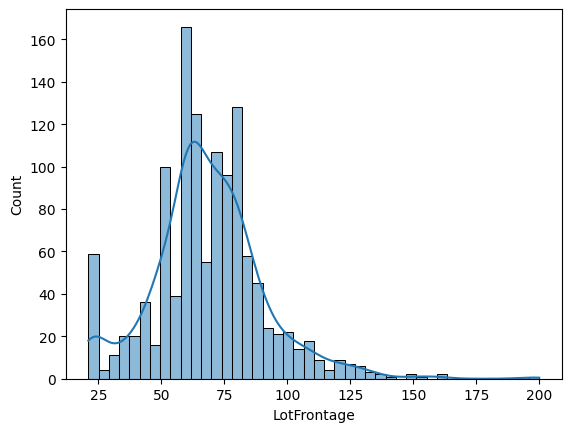

In [28]:
sns.histplot(df["LotFrontage"], kde=True)
plt.show()

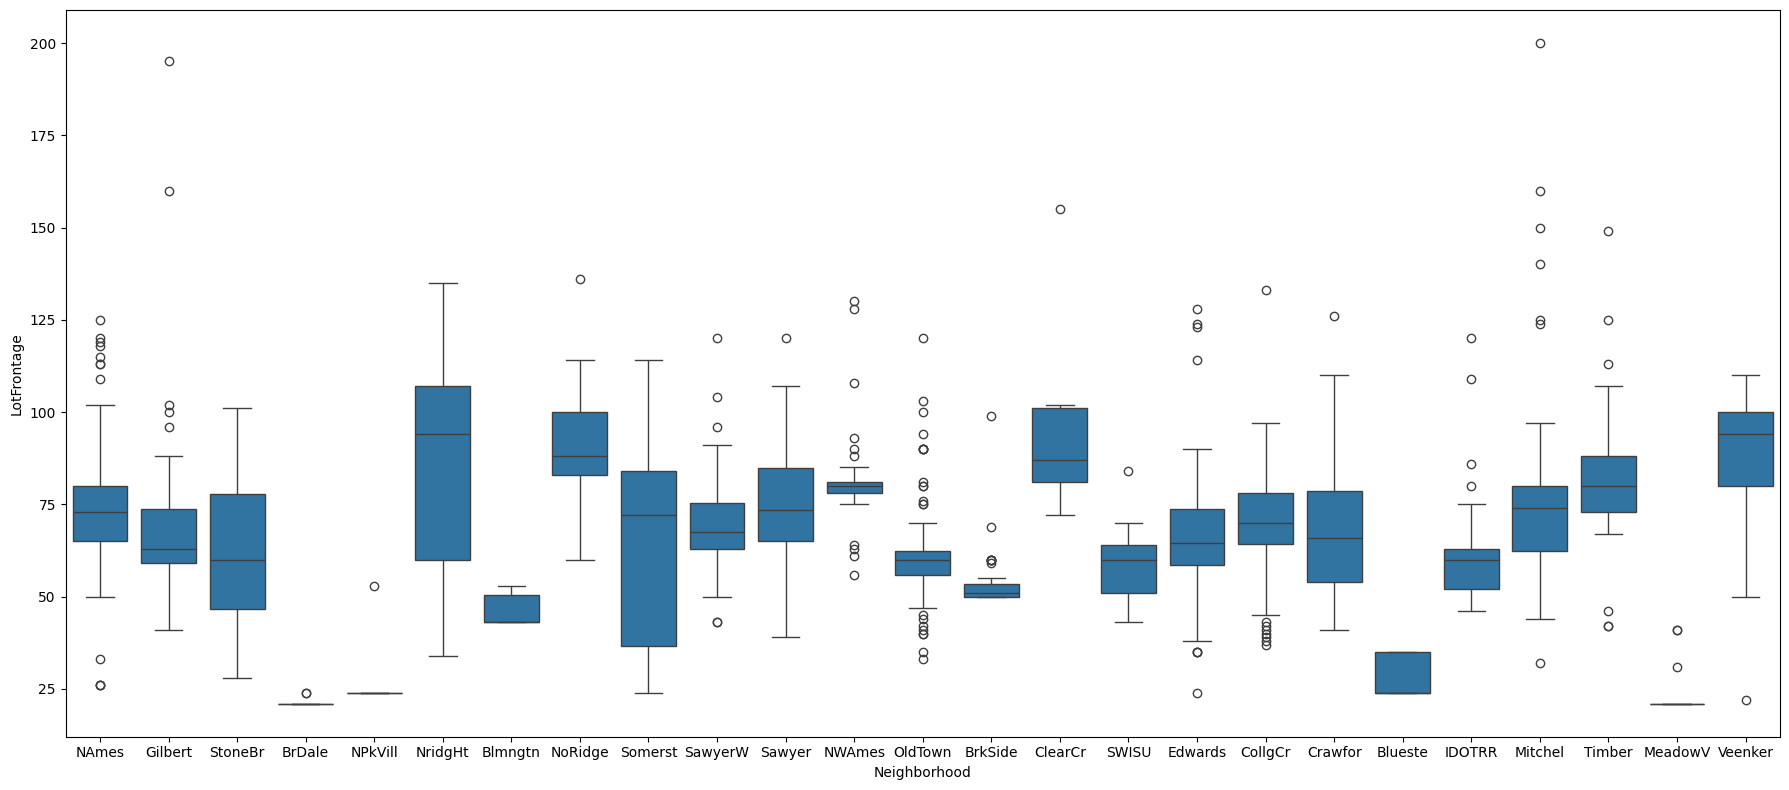

In [29]:
plt.figure(figsize=(18, 8))

sns.boxplot(x="Neighborhood", y="LotFrontage", data=df)
plt.tight_layout()
plt.show()

In [30]:
df[["LotFrontage", "LotArea"]].corr()


,LotFrontage,LotArea
LotFrontage,1.000000,0.644608
LotArea,0.644608,1.000000


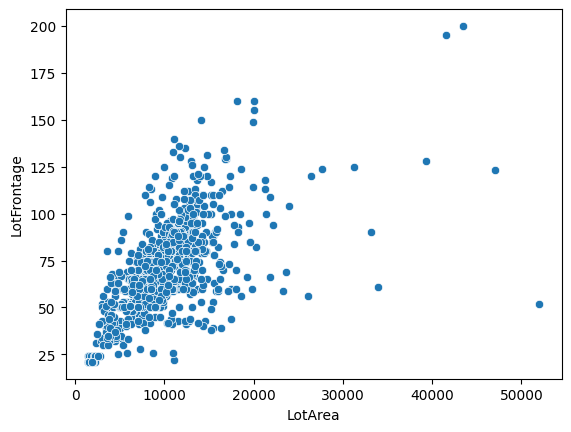

In [31]:
sns.scatterplot(data=df, x="LotArea", y="LotFrontage")
plt.show()

#### Observations

Unlike the previously investigated features, the missing values in `LotFrontage` cannot be interpreted as the absence of a property characteristic, since every residential property is expected to have street frontage. This indicates that the missing values represent genuine missing information rather than structural missingness.

Several potential imputation strategies were considered. A moderate positive correlation (approximately 0.64) was observed between `LotFrontage` and `LotArea`, suggesting that lot size provides useful information for estimating frontage. However, exploratory analysis also revealed noticeable differences in `LotFrontage` distributions across neighborhoods.

The neighborhood boxplots showed that median frontage values vary between neighborhoods, while most neighborhoods exhibit relatively compact interquartile ranges. This indicates that properties within the same neighborhood tend to have similar frontage characteristics, making neighborhood a meaningful contextual variable for estimating missing values.

#### Decision

Given the observed differences in frontage distributions between neighborhoods, imputing missing values using a single global statistic (such as the overall mean or median) would ignore important location-specific characteristics.

Although `LotArea` demonstrates a moderate linear relationship with `LotFrontage`, neighborhood-based median imputation provides a simple, interpretable, and context-aware strategy that preserves local property characteristics without introducing the complexity of predictive imputation.

Therefore, missing values in `LotFrontage` will be imputed using the median `LotFrontage` of the corresponding neighborhood.

### Row-wise Missingness Investigation

In [32]:
missing_per_row = df.isnull().sum(axis=1)

missing_per_row.value_counts().sort_values()


14      1
17      1
8       2
13      2
2       2
15      2
16      4
9       7
12     11
10     36
7      45
11     47
3      55
6     338
4     403
5     503
Name: count, dtype: int64

In [33]:
row = missing_per_row.idxmax()
df.loc[row, df.loc[row].isna()]

LotFrontage     NaN
Alley           NaN
MasVnrType      NaN
BsmtQual        NaN
BsmtCond        NaN
BsmtExposure    NaN
BsmtFinType1    NaN
BsmtFinType2    NaN
FireplaceQu     NaN
GarageType      NaN
GarageYrBlt     NaN
GarageFinish    NaN
GarageQual      NaN
GarageCond      NaN
PoolQC          NaN
Fence           NaN
MiscFeature     NaN
Name: 387, dtype: object

#### Observations

Although some observations contain a relatively large number of missing values, row-wise inspection revealed that these missing values are primarily explained by the absence of multiple optional property features (e.g., garage, basement, pool, fireplace, alley, and fence) rather than widespread data corruption.

For example, the observation with the highest number of missing values (17) is missing predominantly structural features that represent property amenities not present in the house. Only a small number of missing values within such observations correspond to genuine missing information requiring imputation.

#### Conclusion

The row-wise investigation confirms that a high missing-value count does not necessarily indicate poor data quality. Consequently, observations will not be removed solely based on the number of missing values. Instead, each missing value will be handled according to the missingness mechanism identified during the feature-level investigations.

### Tiny Missing Value Features

In [34]:
small_cat = [
    "MSZoning",
    "Utilities",
    "Functional",
    "Exterior1st",
    "Exterior2nd",
    "SaleType",
    "KitchenQual",
]

for col in small_cat:
    print()
    print(df[col].value_counts(dropna=False))



MSZoning
RL         1114
RM          242
FV           74
C (all)      15
RH           10
NaN           4
Name: count, dtype: int64

Utilities
AllPub    1457
NaN          2
Name: count, dtype: int64

Functional
Typ     1357
Min2      36
Min1      34
Mod       20
Maj1       5
Maj2       4
NaN        2
Sev        1
Name: count, dtype: int64

Exterior1st
VinylSd    510
MetalSd    230
HdBoard    220
Wd Sdng    205
Plywood    113
CemntBd     65
BrkFace     37
WdShing     30
AsbShng     24
Stucco      18
BrkComm      4
AsphShn      1
NaN          1
CBlock       1
Name: count, dtype: int64

Exterior2nd
VinylSd    510
MetalSd    233
HdBoard    199
Wd Sdng    194
Plywood    128
CmentBd     66
Wd Shng     43
BrkFace     22
Stucco      21
AsbShng     18
Brk Cmn     15
ImStucc      5
CBlock       2
AsphShn      1
NaN          1
Stone        1
Name: count, dtype: int64

SaleType
WD       1258
New       117
COD        44
ConLD      17
CWD         8
Oth         4
ConLI       4
Con         3
ConLw    

In [35]:
small_num = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
    "GarageCars",
    "GarageArea",
]

df[small_num].describe()


,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath,GarageCars,GarageArea
count,1458.000000,1458.000000,1458.000000,1458.000000,1457.000000,1457.000000,1458.000000,1458.000000
mean,439.203704,52.619342,554.294925,1046.117970,0.434454,0.065202,1.766118,472.768861
std,455.268042,176.753926,437.260486,442.898624,0.530648,0.252468,0.775945,217.048611
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,219.250000,784.000000,0.000000,0.000000,1.000000,318.000000
50%,350.500000,0.000000,460.000000,988.000000,0.000000,0.000000,2.000000,480.000000
75%,753.500000,0.000000,797.750000,1305.000000,1.000000,0.000000,2.000000,576.000000
max,4010.000000,1526.000000,2140.000000,5095.000000,3.000000,2.000000,5.000000,1488.000000


#### Observations

The remaining features contain only a very small number of missing values. Investigation showed that these missing values are isolated rather than representing broader missingness patterns.

For categorical features, the distributions are heavily dominated by a single category, making mode imputation an appropriate and low-risk strategy.

For numerical features, the missing values primarily occur within observations already identified during the garage and basement investigations and will therefore be handled consistently with those feature families.

#### Decision

Categorical features with isolated missing values will be imputed using their respective mode, as this preserves the existing distribution while introducing minimal bias.

Numerical features associated with garage and basement measurements will be imputed according to the strategies established during the corresponding feature-family investigations to ensure semantic consistency across related variables.

### Cleaning Strategy Summary

| Feature Group              | Missingness Mechanism | Treatment                        |
| -------------------------- | --------------------- | -------------------------------- |
| PoolQC                     | Structural            | `"None"`                         |
| FireplaceQu                | Structural            | `"None"`                         |
| Garage (Categorical)       | Structural            | `"None"`                         |
| Garage (Numerical)         | Structural            | `0` (or appropriate value)       |
| Basement (Categorical)     | Structural            | `"None"`                         |
| Basement (Numerical)       | Structural            | `0`                              |
| MasVnrType                 | Mixed                 | `"None"` for structural cases    |
| MasVnrArea                 | Genuine Missing       | Appropriate numerical imputation |
| LotFrontage                | Genuine Missing       | Neighborhood median              |
| Small categorical features | Isolated missing      | Mode                             |


## 4. Missing Value Treatment

In [36]:
df_clean = df.copy()

In [37]:
amenity_features = ["PoolQC", "MiscFeature", "Alley", "Fence", "FireplaceQu"]

df_clean[amenity_features] = df_clean[amenity_features].fillna("None")


In [38]:
df_clean[amenity_features].isnull().sum()


PoolQC         0
MiscFeature    0
Alley          0
Fence          0
FireplaceQu    0
dtype: int64

In [39]:
garage_cat = ["GarageType", "GarageFinish", "GarageQual", "GarageCond"]

df_clean[garage_cat] = df_clean[garage_cat].fillna("None")


In [40]:
df_clean[garage_cat].isnull().sum()

GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
dtype: int64

In [41]:
garage_num_zero = ["GarageCars", "GarageArea"]

df_clean[garage_num_zero] = df_clean[garage_num_zero].fillna(0)

df_clean["GarageYrBlt"] = df_clean["GarageYrBlt"].fillna(-1) # check


GarageYrBlt was imputed with -1 as a sentinel value to explicitly represent the absence of a garage. This value does not correspond to a valid construction year and will be interpreted accordingly during subsequent feature engineering.

In [42]:
df_clean[garage_num_zero + ['GarageYrBlt']].isnull().sum()

GarageCars     0
GarageArea     0
GarageYrBlt    0
dtype: int64

In [43]:
bsmt_cat = ["BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2"]

df_clean[bsmt_cat] = df_clean[bsmt_cat].fillna("None")


In [44]:
df_clean[bsmt_cat].isnull().sum()


BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
dtype: int64

In [45]:
bsmt_num = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath",
]

df_clean[bsmt_num] = df_clean[bsmt_num].fillna(0)


In [46]:
df_clean[bsmt_num].isnull().sum()


BsmtFinSF1      0
BsmtFinSF2      0
BsmtUnfSF       0
TotalBsmtSF     0
BsmtFullBath    0
BsmtHalfBath    0
dtype: int64

In [47]:
df_clean["MasVnrType"] = df_clean["MasVnrType"].fillna("None")


In [48]:
df_clean[df_clean["MasVnrArea"].isna()][["MasVnrType", "MasVnrArea"]]


,MasVnrType,MasVnrArea
231,None,NaN
246,None,NaN
422,None,NaN
532,None,NaN
544,None,NaN
581,None,NaN
851,None,NaN
865,None,NaN
880,None,NaN
889,None,NaN


In [49]:
df_clean["MasVnrArea"] = df_clean["MasVnrArea"].fillna(0)


In [50]:
df_clean[["MasVnrType", "MasVnrArea"]].isnull().sum()


MasVnrType    0
MasVnrArea    0
dtype: int64

In [51]:
df_clean.isnull().sum().sort_values(ascending=False).head(10)

LotFrontage    227
MSZoning         4
Utilities        2
Functional       2
Exterior2nd      1
KitchenQual      1
Exterior1st      1
SaleType         1
LotShape         0
LandContour      0
dtype: int64

In [52]:
df_clean['LotFrontage'] = df_clean.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median())) # learn this code style

In [53]:
df_clean['LotFrontage'].isnull().sum()

np.int64(0)

In [54]:
small_cat = [
    "MSZoning",
    "Utilities",
    "Functional",
    "Exterior1st",
    "Exterior2nd",
    "SaleType",
    "KitchenQual",
]

for col in small_cat:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])


In [55]:
df_clean.isnull().sum().sum()

np.int64(0)

In [56]:
print(df.shape)
print(df_clean.shape)

(1459, 80)
(1459, 80)


,Before,After
Id,0,0
MSSubClass,0,0
MSZoning,4,0
LotFrontage,227,0
LotArea,0,0
...,...,...
MiscVal,0,0
MoSold,0,0
YrSold,0,0
SaleType,1,0


### Key Takeaways

- Missing values should not be treated as a single problem.
- Structural missingness should be distinguished from genuine missing information.
- Business understanding should guide imputation decisions.